Linear regression


line equation 
y=mx+c----
m=slope of the axis
c=intercept

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#df=pd.DataFrame({
 #   "Car_age":[1,2,3,4,5,6,7,8,9,10],
#    "Selling_price":[950,900,850,800,750,700,650,600,550,500]

#})

df =pd.DataFrame ({
    "Employee_ID": [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120],
    "Experience": [1, 2, 3, 4, 5, np.nan, 7, 8, 9, 10, 2, 3, np.nan, 5, 6, 8, 9, 10, 4, 4],
    "Salary": [30000, 35000, 40000, np.nan, 50000, 55000, 60000, 65000, 70000, 75000, 36000, np.nan, 52000, 51000, 56000, 180000, 15000, 76000, 45000, 45000]
})

df

,Employee_ID,Experience,Salary
0,101,1.0,30000.0
1,102,2.0,35000.0
2,103,3.0,40000.0
3,104,4.0,NaN
4,105,5.0,50000.0
5,106,NaN,55000.0
6,107,7.0,60000.0
7,108,8.0,65000.0
8,109,9.0,70000.0
9,110,10.0,75000.0


In [5]:
con=df.select_dtypes(include=['number']).columns.to_list()

In [6]:
print(con)

['Employee_ID', 'Experience', 'Salary']


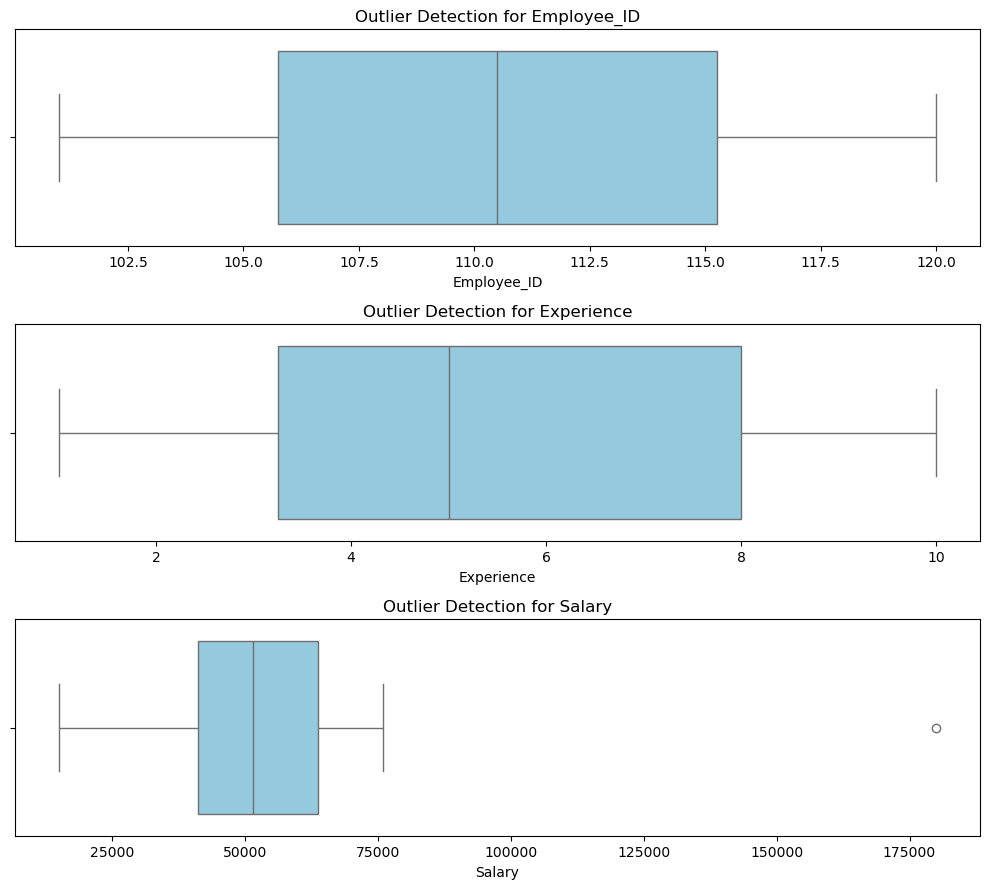

In [7]:

plt.figure(figsize=(10, 3 * len(con)))


for i, col in enumerate(con, 1):
    plt.subplot(len(con), 1, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Outlier Detection for {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

In [8]:


for col in con:
    mean_value = df[col].mean()
    df[col] = df[col].fillna(mean_value)




In [9]:
# TODO: write your code here

for col in con:
   
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    qr = q3 - q1
    
    ll = q1 - 1.5 * qr
    ul = q3 + 1.5 * qr
    
    
    df[col] = np.where(df[col] < ll, ll, df[col])
    
   
    df[col] = np.where(df[col] > ul, ul, df[col])





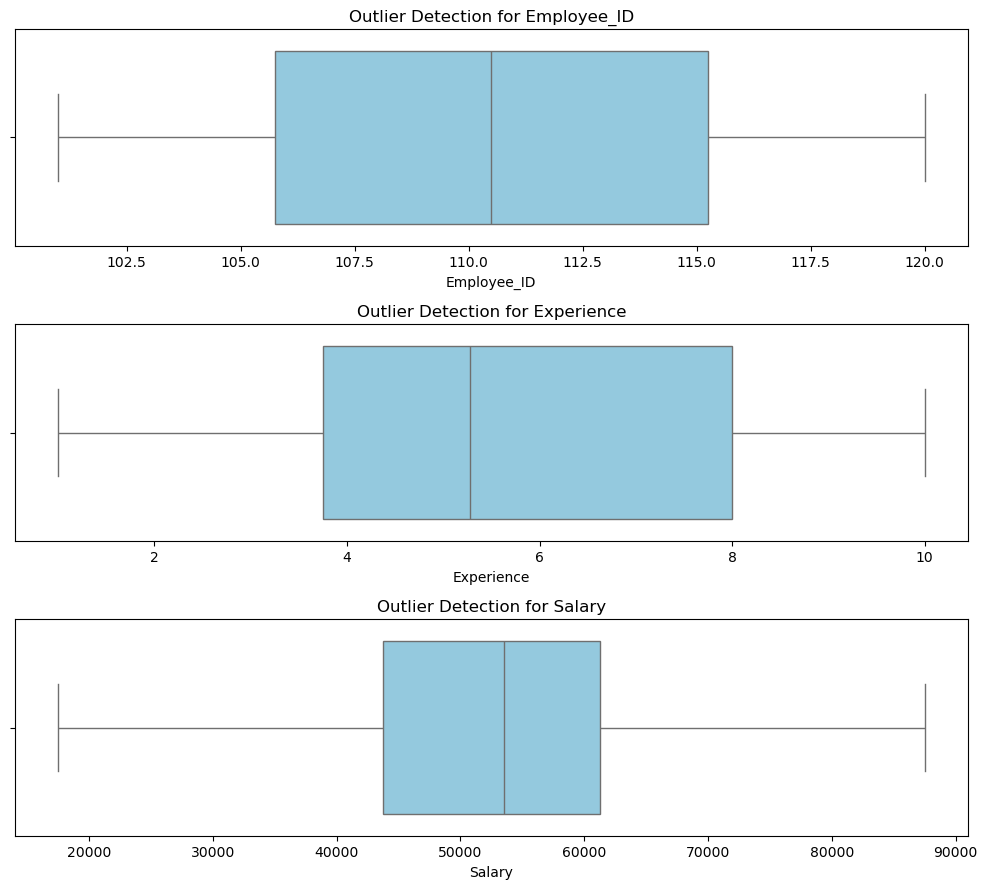

In [10]:
plt.figure(figsize=(10, 3 * len(con)))


for i, col in enumerate(con, 1):
    plt.subplot(len(con), 1, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Outlier Detection for {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

In [11]:
df

,Employee_ID,Experience,Salary
0,101.0,1.000000,30000.000000
1,102.0,2.000000,35000.000000
2,103.0,3.000000,40000.000000
3,104.0,4.000000,57555.555556
4,105.0,5.000000,50000.000000
5,106.0,5.555556,55000.000000
6,107.0,7.000000,60000.000000
7,108.0,8.000000,65000.000000
8,109.0,9.000000,70000.000000
9,110.0,10.000000,75000.000000


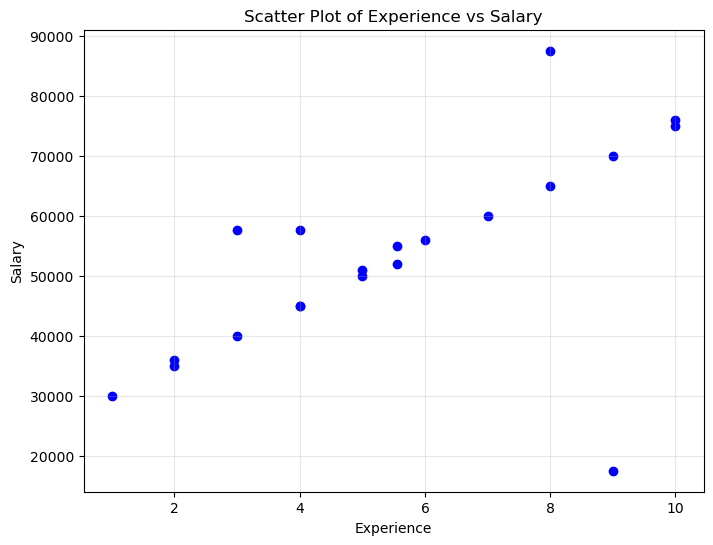

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(df["Experience"], df["Salary"], c='blue', alpha=1)

plt.title("Scatter Plot of Experience vs Salary")

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.grid(alpha=0.3)
plt.show()

Assume a Line

In [13]:
m=-54

c=30000

df["Prediction"]=m*df["Experience"]+c

df

,Employee_ID,Experience,Salary,Prediction
0,101.0,1.000000,30000.000000,29946.0
1,102.0,2.000000,35000.000000,29892.0
2,103.0,3.000000,40000.000000,29838.0
3,104.0,4.000000,57555.555556,29784.0
4,105.0,5.000000,50000.000000,29730.0
5,106.0,5.555556,55000.000000,29700.0
6,107.0,7.000000,60000.000000,29622.0
7,108.0,8.000000,65000.000000,29568.0
8,109.0,9.000000,70000.000000,29514.0
9,110.0,10.000000,75000.000000,29460.0


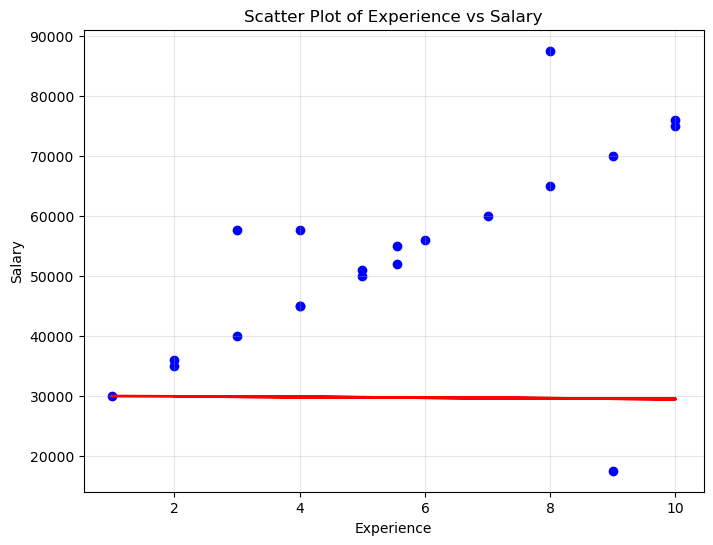

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(df["Experience"], df["Salary"], c='blue', alpha=1)
plt.plot(df["Experience"],df["Prediction"],color="red",linewidth=2,label="Predicted Line")

plt.title("Scatter Plot of Experience vs Salary")

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.grid(alpha=0.3)
plt.show()

In [15]:
l = []
i=0
for x in df["Employee_ID"]:
    l=df["Salary"]-df["Prediction"]
    print(l[i])
    i=i+1

54.0
5108.0
10162.0
27771.555555555555
20270.0
25300.0
30378.0
35432.0
40486.0
45540.0
6108.0
27717.555555555555
22300.0
21270.0
26324.0
57932.0
-12014.0
46540.0
15216.0
15216.0


Using Formula

In [16]:
x_mean=df["Experience"].mean()

y_mean=df["Salary"].mean()

print(x_mean)
print(y_mean)

5.555555555555555
53055.55555555555


In [17]:
x=df["Experience"].tolist()
y=df["Salary"].tolist()

sum_x=0
sum_y=0;

for i in range(len(x)):
    sum_x+=x[i]
    sum_y+=y[i]

x_mea=sum_x/len(x)
y_mea=sum_y/len(y)

print(x_mea)
print(y_mea)

5.555555555555555
53055.55555555555


In [18]:
n=0       #numerator

for i in range(len(x)):
    x_diff=x[i]-x_mea
    y_diff=y[i]-y_mea

    n+=x_diff*y_diff

print(n)

532771.6049382717


In [19]:
d=0  #denominator

for i in range(len(x)):
    x_diff=x[i]-x_mea
    d+=x_diff**2

print(d)

144.44444444444443


In [20]:
m=n/d
print(m)

3688.4188034188046


In [21]:
b=y_mea-(m*x_mea)
print(b)

32564.339981006633


In [22]:
df["Prediction_formula"]=m*df["Experience"]+b
df

,Employee_ID,Experience,Salary,Prediction,Prediction_formula
0,101.0,1.000000,30000.000000,29946.0,36252.758784
1,102.0,2.000000,35000.000000,29892.0,39941.177588
2,103.0,3.000000,40000.000000,29838.0,43629.596391
3,104.0,4.000000,57555.555556,29784.0,47318.015195
4,105.0,5.000000,50000.000000,29730.0,51006.433998
5,106.0,5.555556,55000.000000,29700.0,53055.555556
6,107.0,7.000000,60000.000000,29622.0,58383.271605
7,108.0,8.000000,65000.000000,29568.0,62071.690408
8,109.0,9.000000,70000.000000,29514.0,65760.109212
9,110.0,10.000000,75000.000000,29460.0,69448.528015


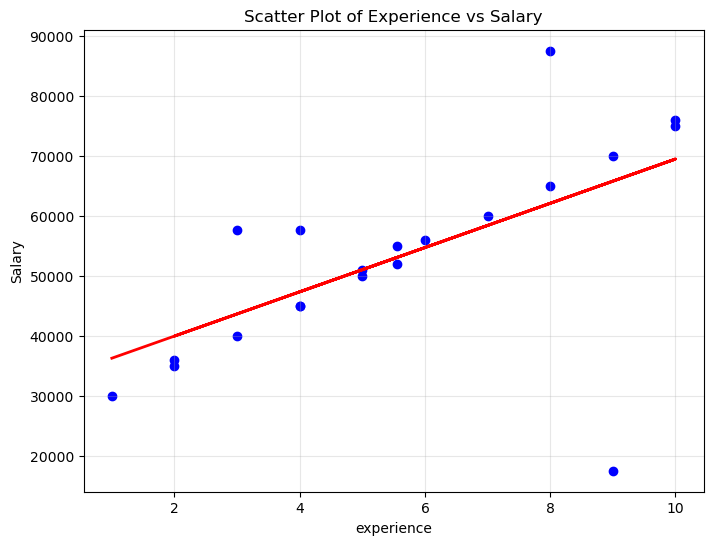

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(df["Experience"], df["Salary"], c='blue', alpha=1)
plt.plot(df["Experience"],df["Prediction_formula"],color="red",linewidth=2,label="Predicted Line")

plt.title("Scatter Plot of Experience vs Salary")

plt.xlabel("experience")
plt.ylabel("Salary")
plt.grid(alpha=0.3)
plt.show()

In [24]:
l = []
i=0
for x in df["Employee_ID"]:
    l=df["Salary"]-df["Prediction"]
    print(l[i])
    i=i+1

54.0
5108.0
10162.0
27771.555555555555
20270.0
25300.0
30378.0
35432.0
40486.0
45540.0
6108.0
27717.555555555555
22300.0
21270.0
26324.0
57932.0
-12014.0
46540.0
15216.0
15216.0


using Epochs


In [ ]:
n = 20
epochs = 1000
learning_rate = 0.001


m = 0.0
b = 0.0
x = [i for i in range(n)] 
y = [2 * i + 1 for i in range(n)] 

for epoch in range(epochs):
    dm = 0.0
    db = 0.0
    
    for i in range(n):
        y_pre = m * x[i] + b
        error = y_pre - y[i]
        dm += error * x[i]
        db += error
        
    
    dm = (2 / n) * dm
    db = (2 / n) * db
    
    m = m - learning_rate * dm
    b = b - learning_rate * db
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: m = {m:.4f}, b = {b:.4f}")


Epoch 0: m = 0.5130, b = 0.0400
Epoch 100: m = 2.0614, b = 0.2034
Epoch 200: m = 2.0582, b = 0.2450
Epoch 300: m = 2.0552, b = 0.2843
Epoch 400: m = 2.0523, b = 0.3216
Epoch 500: m = 2.0496, b = 0.3570
Epoch 600: m = 2.0470, b = 0.3905
Epoch 700: m = 2.0445, b = 0.4223
Epoch 800: m = 2.0422, b = 0.4524
Epoch 900: m = 2.0400, b = 0.4810
